In [13]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
smooth_window = 125

df = fg.datasets.bidmc(subject=1)

df['respiration_smooth'] = df['respiration'].rolling(smooth_window).max().rolling(smooth_window).mean().shift(-smooth_window)
df['respiration_rising'] = df['respiration_smooth'].diff() > 0
df['respiration_falling'] = df['respiration_smooth'].diff() < 0
df['respiration_inactive'] = df['respiration_smooth'].diff() == 0

df['enter_respiration_rising'] = df['respiration_rising'].astype(int).diff() == 1
df['exit_respiration_rising'] = df['respiration_rising'].astype(int).diff() == -1

(<Figure size 1600x1540 with 7 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_rising'>,
        <Axes: ylabel='respiration_falling'>,
        <Axes: ylabel='respiration_inactive'>,
        <Axes: ylabel='enter_respiration_rising'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising'>],
       dtype=object))

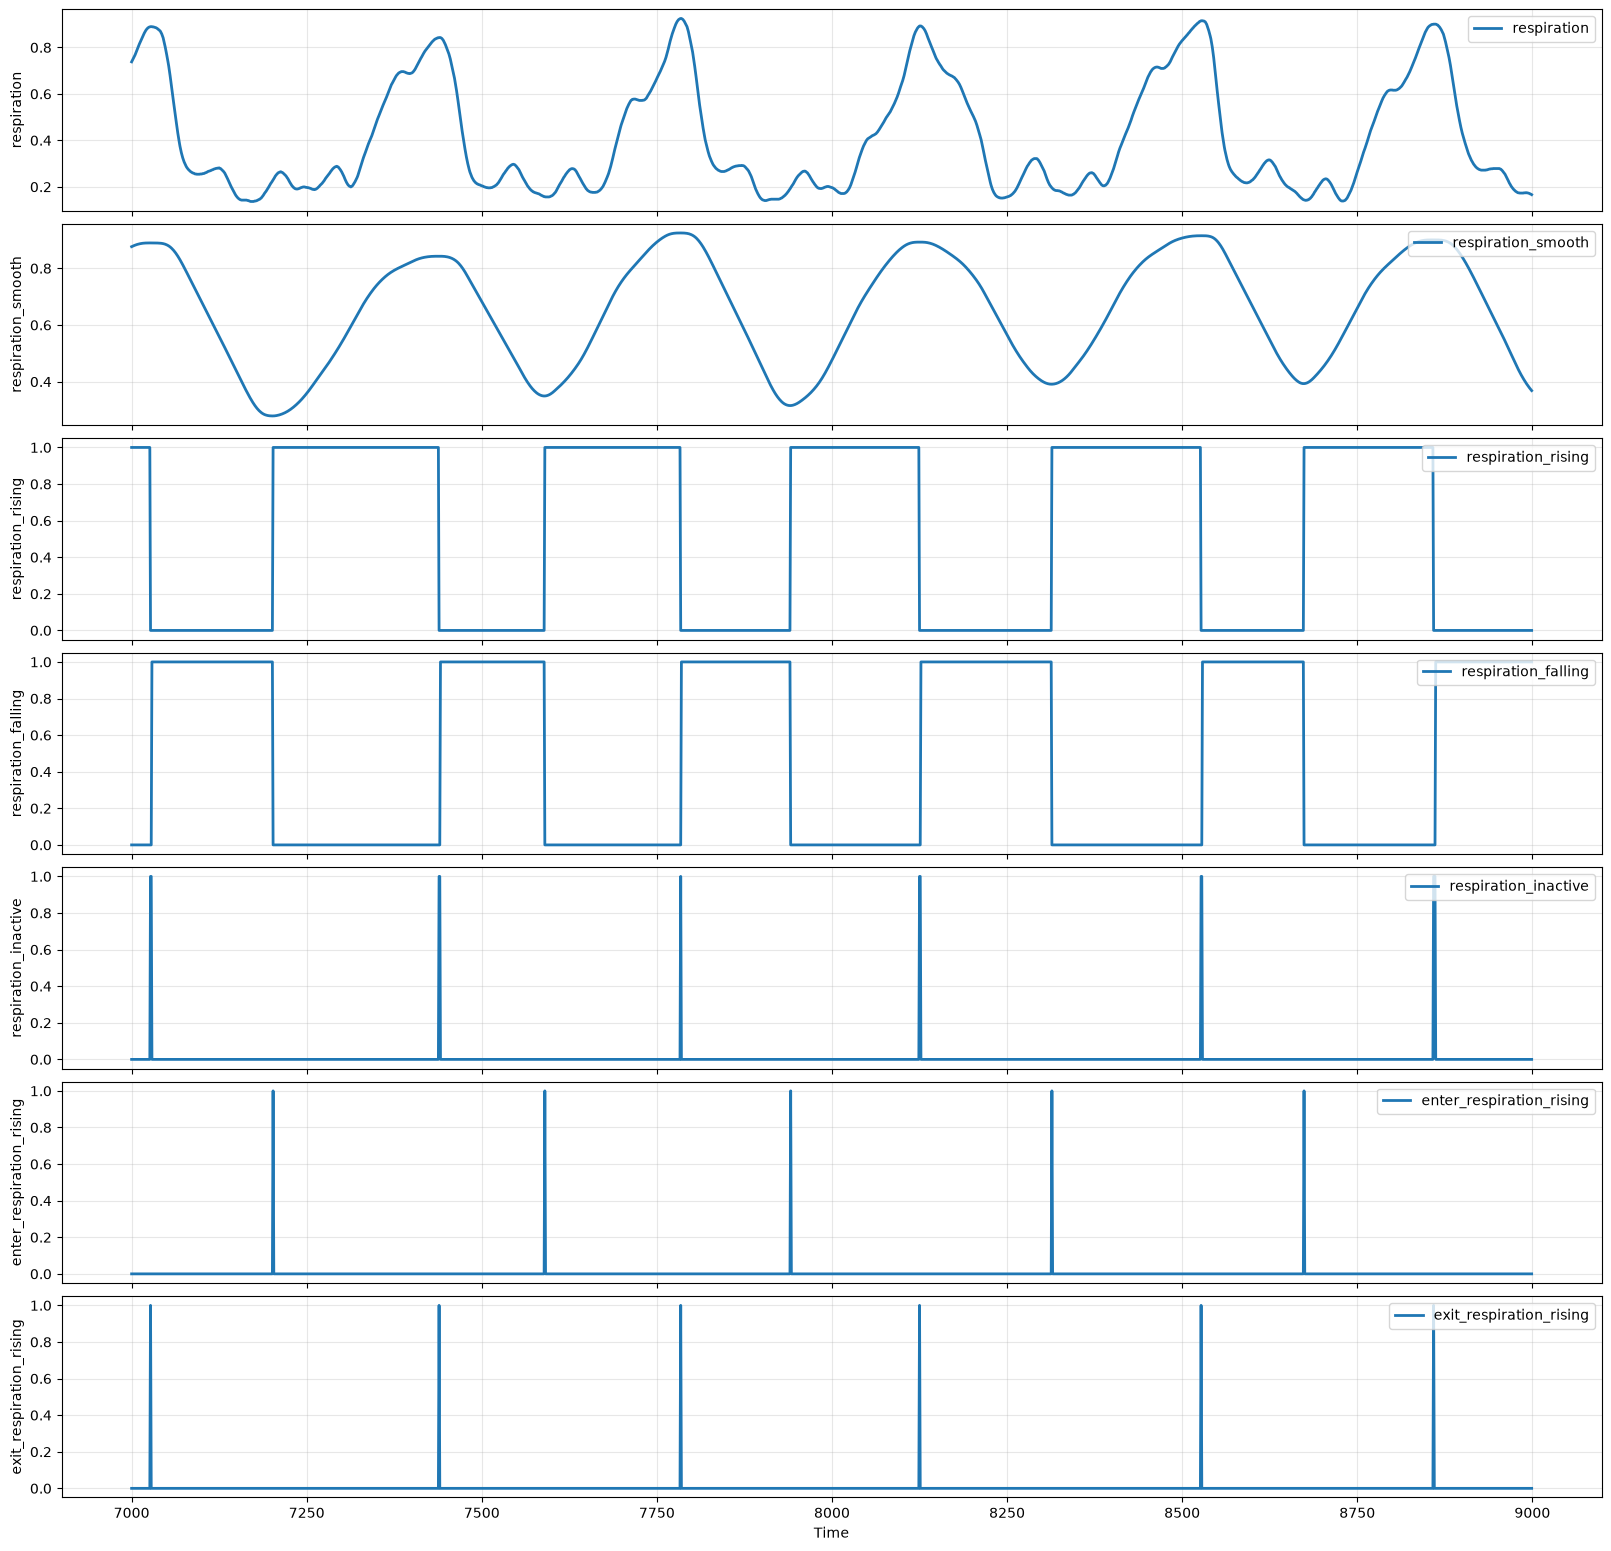

In [15]:
fg.plot(df[7000:9000], [['respiration'],
                              ['respiration_smooth'],
                              ['respiration_rising'],
                              ['respiration_falling'],
                              ['respiration_inactive'],
                              ['enter_respiration_rising'],
                              ['exit_respiration_rising'],
                             ]
)